<a href="https://colab.research.google.com/github/saksham962314/Artificial_Intelligence_Lab_SE_28/blob/master/practical8ds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv


In [ ]:
Mdf= pd.read_csv('movies.csv')

In [ ]:
Mdf.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ratings.csv to ratings.csv


In [ ]:
Rdf = pd.read_csv("ratings.csv")

In [ ]:
Rdf.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [ ]:
data = pd.merge(Rdf, Mdf, on="movieId")
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


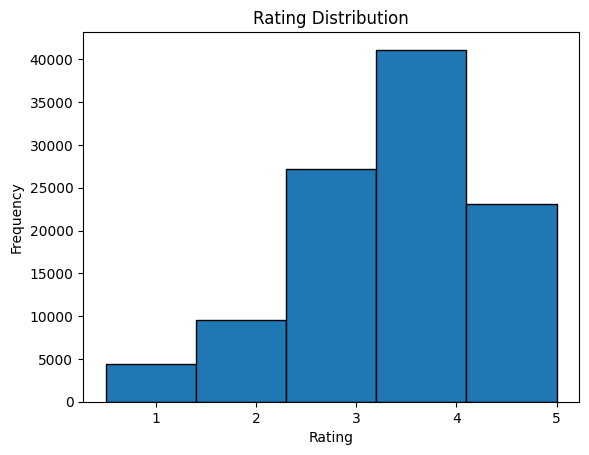

In [ ]:
bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
plt.hist(data['rating'], bins=5, edgecolor='black')

plt.xticks([1, 2, 3, 4, 5])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [ ]:
data['genres'] = data['genres'].astype('category').cat.codes

In [ ]:
X = data[['userId', 'movieId', 'genres']]
y_reg = data['rating']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_reg, test_size=0.2, random_state=42)

In [ ]:
reg = RandomForestRegressor()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(0.9549122030831495)

In [ ]:
data['rating_class'] = np.where(data['rating'] >= 3.5, 1, 0)
y_cls = data['rating_class']

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
X, y_cls, test_size=0.2, random_state=42)

In [ ]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred_cls = clf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_cls))

Accuracy: 0.6583918739320296


In [ ]:
print(classification_report(y_test, y_pred_cls))

              precision    recall  f1-score   support

           0       0.56      0.52      0.54      8129
           1       0.71      0.75      0.73     12939

    accuracy                           0.66     21068
   macro avg       0.64      0.63      0.63     21068
weighted avg       0.65      0.66      0.66     21068

